# Predicción de Suscripción a un Depósito Bancario

- Manuel Manchado Barquero (NIA: 100522228)
- David Mateu Serrano (NIA: 100522337)

[Repositorio Github](https://github.com/100522228/P1_Machine_learning.git)

## EDA
En esta sección realizamos un análisis técnico de los datos para determinar la estrategia de preprocesamiento. El objetivo es identificar la naturaleza de las variables y posibles problemas en el dataset.

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

# Establecemos la semilla para permitir reproducir los resultados
SEED = 100522228
target = 'deposit' # Dejamos creada la variable que se usará más adelante

# Leemos los datos
file_path = Path("content/P1") / "bank_10.pkl"
df = pd.read_pickle(file_path)

# Identificamos el número de instancias y variables
n_instancias, n_variables = df.shape
print(f"El dataset contiene {n_instancias} instancias y {n_variables} variables.")
# Ya que deposit solo contiene los valores si o no, nos encontramos ante un problema de clasificación binaria
print(f"Tipo de problema: Clasificación binaria (Target: '{target}')")

# Vamos a recorrer todas las variables para sacar la información necesaria de cada una
# Listas para clasificar los distintos tipos de datos (las ordinales las introducimos por conocimiento propio, ya que no se pueden distinguir a simple vista de las categóricas)
var_ordinales = ['education', 'month']
var_numericas = []
var_categoricas = []

for col in df.columns:
    if col == target:
        continue
    # Vamos clasificando las variables que nos quedan (numéricas y categóricas)
    if np.issubdtype(df[col].dtype, np.number):
        var_numericas.append(col)
    elif col in var_ordinales:
        continue # Ya está en la lista de ordinales
    else:
        var_categoricas.append(col)

# Una vez que tenemos los tipos de las variables, identificamos la alta cardinalidad (solamente para variables categóricas), las ctes y los ID
alta_cardinalidad = []
columnas_constantes = []
columnas_id = []

# Mostramos los resultados a modo de tabla
print(f"\n{'COLUMNA':<15} | {'TIPO':<12} | {'ÚNICOS':<8} | {'NaN':<5} | {'UNKNOWN':<8}")
print("-" * 65)

for col in df.columns:
    # Además, identificamos los valores únicos (solo para los categóricos), los Nan y los unknown
    n_nan = df[col].isna().sum()
    n_unknown = (df[col] == 'unknown').sum() if df[col].dtype == 'object' else 0
    n_unicos = df[col].nunique()
    
    # Determinamos la etiqueta del tipo
    if col == target:
        tipo_str = "TARGET"
        unicos_display = str(n_unicos)
    elif col in var_numericas:
        tipo_str = "Numérica"
        unicos_display = "-" # No tiene sentido mostrar los valores únicos de una variable numérica
    elif col in var_ordinales:
        tipo_str = "Ordinal"
        unicos_display = str(n_unicos)
        if n_unicos > 10:
            alta_cardinalidad.append(col)
    else:
        tipo_str = "Categórica"
        unicos_display = str(n_unicos)
        if n_unicos > 10:
            alta_cardinalidad.append(col)

    # De cada varible imprimimos su información
    print(f"{col:<15} | {tipo_str:<12} | {unicos_display:<8} | {n_nan:<5} | {n_unknown:<8}")

    # Comprobaciones de integridad (ctes o ID)
    if col != target:
        if n_unicos <= 1:
            columnas_constantes.append(col)
        if n_unicos == n_instancias:
            columnas_id.append(col)

print("-" * 65)

# Imprimimos los resultados adicionales
print(f"\nVariables con alta cardinalidad (>10): {alta_cardinalidad}")
print(f"Columnas constantes: {columnas_constantes}")
print(f"Columnas tipo ID: {columnas_id}")


# Ahora comprobamos el balanceo de deposit. Nuestro objetivo es identificar un posible desbalanceo
counts = df[target].value_counts()
percentages = df[target].value_counts(normalize=True) * 100

print(f"\nBalanceo de la clase '{target}':")
for index in counts.index:
    print(f"{index}: {counts[index]} ({percentages[index]:.2f}%)")

# Realizamos el preprocesado de la variable Pdays (ya que no hay riesgo de data leakage)
n_minus_one = (df['pdays'] == -1).sum()
print(f"\nAnálisis de 'pdays': {n_minus_one} instancias con -1 ({n_minus_one/n_instancias:.2%})")

# Creamos una nueva variable (a continuacíon se incluye una explicación de esta decisión)
df['pdays_contacted'] = (df['pdays'] != -1).astype(int) 
df['pdays'] = df['pdays'].replace(-1, 0)


El dataset contiene 11000 instancias y 17 variables.
Tipo de problema: Clasificación binaria (Target: 'deposit')

COLUMNA         | TIPO         | ÚNICOS   | NaN   | UNKNOWN 
-----------------------------------------------------------------
age             | Numérica     | -        | 0     | 0       
job             | Categórica   | 12       | 332   | 66      
marital         | Categórica   | 3        | 183   | 0       
education       | Ordinal      | 4        | 0     | 494     
default         | Categórica   | 2        | 0     | 0       
balance         | Numérica     | -        | 0     | 0       
housing         | Categórica   | 2        | 0     | 0       
loan            | Categórica   | 2        | 0     | 0       
contact         | Categórica   | 3        | 0     | 2309    
day             | Numérica     | -        | 0     | 0       
month           | Ordinal      | 12       | 0     | 0       
duration        | Numérica     | -        | 0     | 0       
campaign        | Numérica 

En cuanto a la calidad y el tipo de variables, no se han encontrado columnas que sean constantes ni identificadores únicos. Aun así, hay que tener en cuenta que algunas variables, como *job* y *month*, tienen una cardinalidad bastante alta (más de 10 valores distintos). También aparecen valores *unknown* en varias variables, como *poutcome*, *contact* o *education*, entre otras.

En lo que respecta a la variable objetivo, los datos están bastante equilibrados: aproximadamente un 52,55% corresponden a la clase "no" y un 47,45% a la clase "yes".

Por otro lado, la variable *pdays* tiene una característica importante: cerca del 74,57% de los registros tienen el valor -1. Es clave tratar este detalle mediante el preprocesado, el cual, no se basa en cálculos globales como medias o modas, sino en el propio significado de los datos, por ello, no hay riesgo de introducir *data leakage*.

En el preprocesado, primero, se ha creado una nueva variable llamada *pdays_contacted*, que indica si el cliente ha sido contactado antes, vale 1 si sí lo ha sido, y 0 en caso de no contacto o en caso desconocido. Esto ayuda al modelo a captar rápidamente si existe ese historial previo sin tener que recurrir a *pdays*. Además, en la variable original *pdays*, se han sustituido los valores -1 por 0. Así, la variable pasa a tener únicamente valores numéricos coherentes, representando el tiempo desde el último contacto. Con esto evitamos problemas donde un -1 podría interpretarse como un valor menor que 0 días y afectar a los resultados.


## Definición evaluación

Para la evaluación externa usaremos un Holdout dividiendo los datos en 2/3 para entrenamiento y 1/3 para test. Dado que las clases de la variable deposit están balanceadas, el Accuracy es una métrica robusta para medir el rendimiento real. 

In [3]:
from sklearn.model_selection import train_test_split

# Definimos X (predictores) e y (objetivo) 
X = df.drop(columns=[target])
y = df[target]

# Realizamos el split 1/3 para test y 2/3 para entrenamiento
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.33, 
    random_state=SEED, 
    stratify=y # Mantiene la proporción de la clase 'deposit'
)


In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer

# Definimos la validación cruzada de 3 folds
cv_inner = KFold(n_splits=3, shuffle=True, random_state=SEED)

scalers = {
    'Standard': StandardScaler(),
    'MinMax': MinMaxScaler(),
    'Robust': RobustScaler(),
    'No Scaler': 'passthrough'
}

results_unknown = {}
results_nada = {}


for name, scaler in scalers.items():

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', scaler, var_numericas),
            ('cat', OneHotEncoder(handle_unknown='ignore'), var_categoricas_y_ordinales),
        ],
        remainder='passthrough' # Ignora la feature contacts pq 'hacemos el one hot encoder a mano'
    )

    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('model', KNeighborsClassifier())
    ])

    scores = cross_val_score(
        pipeline,
        X_train_u,
        y_train_u,
        cv=cv_inner,
        scoring='accuracy'
    )

    results_unknown[name] = {
        'mean': scores.mean(),
        'std': scores.std()
    }

    print(f"{name:<12} | Accuracy media: {scores.mean():.4f} (+/- {scores.std():.4f})")

best_scaler_unknown = max(results_unknown, key=lambda x: results_unknown[x]['mean'])
print(f"\nEl mejor escalador para UNKNOWN es: {best_scaler_unknown}\n")


for name, scaler in scalers.items():

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', scaler, var_numericas),
            ('cat', OneHotEncoder(handle_unknown='ignore'), var_categoricas_y_ordinales),
        ],
        remainder='passthrough' # Ignora la feature contacts
    )

    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('model', KNeighborsClassifier())
    ])

    scores = cross_val_score(
        pipeline,
        X_train_n,
        y_train_n,
        cv=cv_inner,
        scoring='accuracy'
    )

    results_nada[name] = {
        'mean': scores.mean(),
        'std': scores.std()
    }

    print(f"{name:<12} | Accuracy media: {scores.mean():.4f} (+/- {scores.std():.4f})")

best_scaler_nada = max(results_nada, key=lambda x: results_nada[x]['mean'])
print(f"\nEl mejor escalador para NADA es: {best_scaler_nada}")


NameError: name 'var_categoricas_y_ordinales' is not defined

### Evaluación con parámetros por omisión y Tiempos

In [ ]:
import time
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

# 1. Definimos el preprocesador ganador (StandardScaler)
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), var_numericas),
    ('cat', OneHotEncoder(handle_unknown='ignore'), var_categoricas_y_ordinales)
])

# 2. Modelos a evaluar (incluimos el Dummy para las conclusiones finales)
models_default = {
    'Dummy (Most Frequent)': DummyClassifier(strategy='most_frequent'),
    'KNN (Default)': KNeighborsClassifier(),
    'Tree (Default)': DecisionTreeClassifier(random_state=SEED)
}

results_default = []

for name, model in models_default.items():
    pipeline = Pipeline([('prep', preprocessor), ('model', model)])
    
    # Medimos tiempo y precisión
    start_time = time.perf_counter()
    scores = cross_val_score(pipeline, X_train_u, y_train_u, cv=cv_inner, scoring='accuracy')
    elapsed_time = time.perf_counter() - start_time
    
    results_default.append({
        'Método': name,
        'Accuracy Media': scores.mean(),
        'Desviación': scores.std(),
        'Tiempo (s)': elapsed_time
    })

df_results_default = pd.DataFrame(results_default)
print("--- Resultados por Omisión ---")
print(df_results_default)

--- Resultados por Omisión ---
                  Método  Accuracy Media  Desviación  Tiempo (s)
0  Dummy (Most Frequent)        0.527951    0.007814    0.098809
1          KNN (Default)        0.784940    0.007144    0.237144
2         Tree (Default)        0.764180    0.007803    0.243085


 ### Árboles poco profundos (Interpretación)

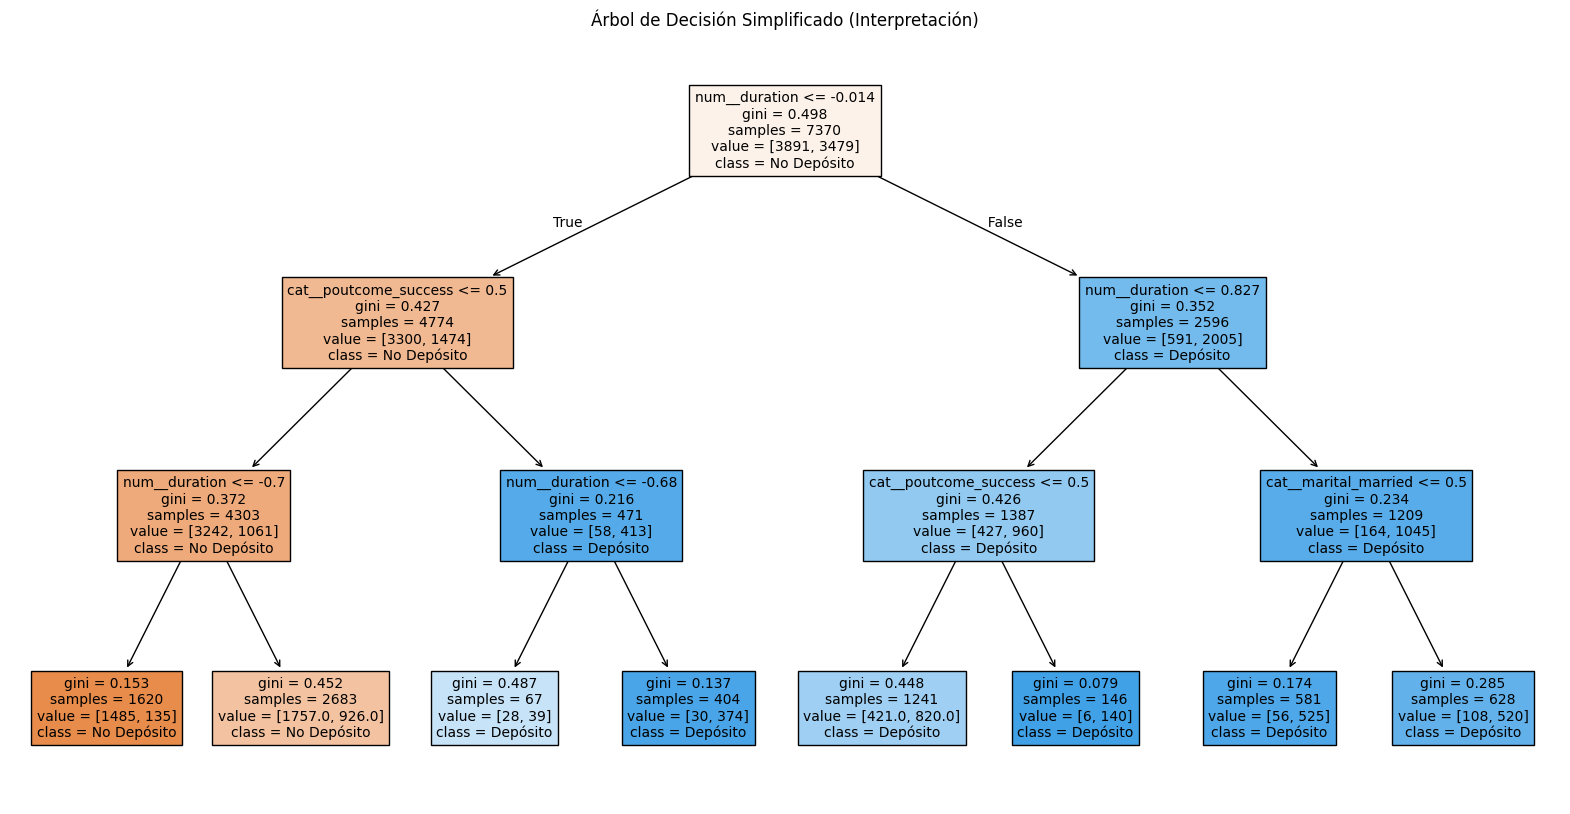

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Entrenamos un árbol con profundidad 3
short_tree_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=3, random_state=SEED))
])
short_tree_pipe.fit(X_train_u, y_train_u)

# Visualización
plt.figure(figsize=(20, 10))
feature_names = short_tree_pipe.named_steps['prep'].get_feature_names_out()
plot_tree(short_tree_pipe.named_steps['model'], 
          feature_names=feature_names,
          filled=True, 
          class_names=['No Depósito', 'Depósito'], 
          fontsize=10)
plt.title("Árbol de Decisión Simplificado (Interpretación)")
plt.show()

### Optimización (HPO) y Análisis de Hiperparámetros

NameError: name 'param_knn' is not defined

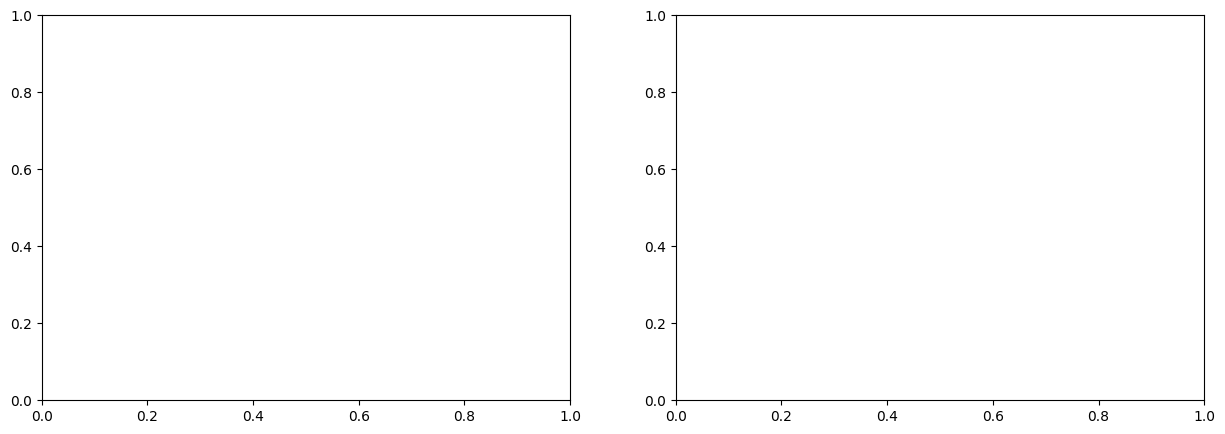

In [ ]:
# --- Visualización del efecto de parámetros (Punto 2.d) ---
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# 1. Gráfico KNN: Efecto del número de vecinos
ax[0].plot(param_knn['model__n_neighbors'], grid_knn.cv_results_['mean_test_score'], 
           marker='o', linestyle='-', color='blue')
ax[0].set_title('Efecto de N-Neighbors en KNN')
ax[0].set_xlabel('Número de Vecinos (k)')
ax[0].set_ylabel('Accuracy (Validación Inner)')
ax[0].grid(True, linestyle='--', alpha=0.7)

# 2. Gráfico Árbol: Efecto de la profundidad (Corregido)
tree_results = pd.DataFrame(grid_tree.cv_results_)
# Filtramos para mostrar solo los resultados con un valor fijo de min_samples_leaf (ej: 5)
mask = tree_results['param_model__min_samples_leaf'] == 5
best_leaf_results = tree_results[mask].copy()

# Convertimos explícitamente a string y manejamos el valor 'None' para que no de error
x_labels = best_leaf_results['param_model__max_depth'].apply(lambda x: 'None' if x is None else str(x))

ax[1].plot(x_labels, best_leaf_results['mean_test_score'], 
           marker='o', linestyle='-', color='green')
ax[1].set_title('Efecto de Max Depth en Árbol (min_samples_leaf=5)')
ax[1].set_xlabel('Profundidad Máxima (max_depth)')
ax[1].set_ylabel('Accuracy (Validación Inner)')
ax[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Conclusiones: Métodos Básicos (KNN y Árboles)

Tras completar el análisis de los métodos básicos siguiendo los pasos de la práctica, se extraen las siguientes conclusiones detalladas:

#### Mejor método y rendimiento
El mejor modelo tras la optimización de hiperparámetros (HPO) es el **Árbol de Decisión**, alcanzando una precisión (*accuracy*) aproximada de **0.793** con una profundidad máxima de **10**. Supera ligeramente al mejor **KNN** ($k = 11$), que obtiene un **0.791**.

#### Comparación con modelos triviales
Ambos métodos son significativamente superiores al modelo **Dummy (Most Frequent)**, que solo alcanza un **0.5279** de *accuracy*. Esto demuestra que los modelos están aprendiendo patrones reales de los datos demográficos y financieros de los clientes.

#### Análisis del coste computacional
- El entrenamiento con hiperparámetros por omisión es sumamente rápido (~0.24 segundos para ambos).
- El ajuste de hiperparámetros (HPO) incrementa el tiempo de ejecución debido a la búsqueda en la rejilla (*grid*), pero la mejora en la precisión justifica este coste, ya que sigue siendo procesable en pocos segundos.

#### Efecto de los hiperparámetros
- **Árboles de Decisión**:  
  Se observa que el modelo requiere una profundidad moderada (`max_depth = 10`). Profundidades muy bajas (2 o 5) limitan la capacidad de aprendizaje (*underfitting*), mientras que una profundidad ilimitada (`None`) tiende a reducir el rendimiento por sobreajuste (*overfitting*).

- **KNN**:  
  El rendimiento óptimo se encuentra en $k = 11$. Un número de vecinos muy bajo captura ruido, mientras que un $k$ excesivamente alto suaviza demasiado las fronteras de decisión.

#### Interpretación del modelo
Mediante el uso de árboles poco profundos ($depth = 3$), se identifica que la variable **`duration`** (duración del último contacto) es el predictor más crítico en la raíz del árbol, seguido por el éxito de campañas anteriores (**`poutcome_success`**).